## Variance detection (seperating noise from real data)

In [29]:
import pandas as pd

df = pd.read_csv("data/streamingtech_session_depth.csv", parse_dates=["date"])
df.head()

,day_index,date,day_of_week,session_depth,period
0,1,2026-01-01,Thursday,4.91,baseline
1,2,2026-01-02,Friday,4.47,baseline
2,3,2026-01-03,Saturday,5.45,baseline
3,4,2026-01-04,Sunday,6.02,baseline
4,5,2026-01-05,Monday,4.28,baseline


### step 2 

### Control zones (Western Electric rules)

Mean, σ, and the zone boundaries are calculated from the **baseline period only** — that's the known-stable reference window. Including `degradation`/`recovery`/`final_stable` in the calculation would inflate σ and widen the limits, absorbing the very degradation we're trying to detect into "normal." The fixed baseline-derived limits are then applied across the full timeline so later periods can be judged against it.

Each side of the mean is split into three 1-standard-deviation-wide bands, used to judge how far a point has drifted from the mean before it actually breaches the control limits:

- **Zone C** — mean ± 1σ. Closest to the mean; ordinary noise.
- **Zone B** — 1σ to 2σ from the mean. Moderate deviation.
- **Zone A** — 2σ to 3σ from the mean. Still technically "in control," but worth watching.
- **Beyond limits** — outside ± 3σ (UCL/LCL). Out of control.

Each point is labeled with the zone it falls in (and whether it's above or below the mean), which sets up rule-based checks later (e.g. "2 of 3 consecutive points in Zone A," "8 points in a row on one side of the mean").

In [38]:
baseline_df = df[df["period"] == "baseline"]

mean_val = baseline_df["session_depth"].mean()
std_val = baseline_df["session_depth"].std()
ucl = mean_val + 3 * std_val
lcl = mean_val - 3 * std_val

def classify_zone(sigma_dist):
    side = "upper" if sigma_dist >= 0 else "lower"
    abs_dist = abs(sigma_dist)
    if abs_dist > 3:
        return "Beyond limits"
    elif abs_dist > 2:
        return f"A ({side})"
    elif abs_dist > 1:
        return f"B ({side})"
    else:
        return f"C ({side})"

df["sigma_from_mean"] = (df["session_depth"] - mean_val) / std_val
df["zone"] = df["sigma_from_mean"].apply(classify_zone)

df["zone"].value_counts()

zone
C (lower)    33
C (upper)    30
B (lower)    11
B (upper)    10
A (upper)     4
A (lower)     2
Name: count, dtype: int64

**Note:** `mean_val`, `std_val`, `ucl`, and `lcl` are always calculated from the `baseline` period only — that's the known-normal window. They're then held fixed and reused as-is against every other period (including in the chart below, which plots the full timeline), so degradation shows up as a deviation from a stable reference instead of getting absorbed into a recalculated average.

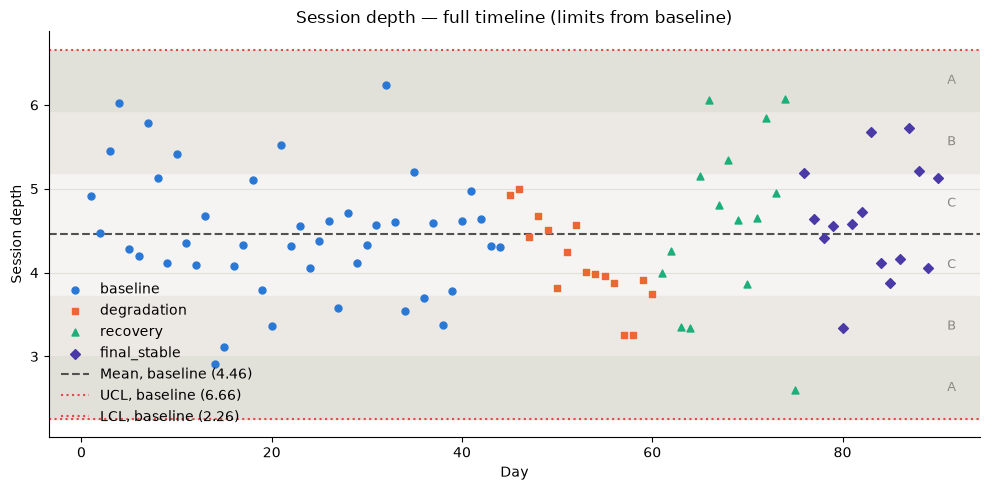

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Shaded zones (C closest to mean, A closest to the control limits), mirrored above/below
zone_bounds = [(1, "#f5f4f2"), (2, "#ece9e4"), (3, "#e1e0d9")]
prev = 0
for n_sigma, color in zone_bounds:
    ax.axhspan(mean_val + prev * std_val, mean_val + n_sigma * std_val, color=color, zorder=0)
    ax.axhspan(mean_val - n_sigma * std_val, mean_val - prev * std_val, color=color, zorder=0)
    prev = n_sigma

for label, n_sigma in [("C", 1), ("B", 2), ("A", 3)]:
    ax.text(df["day_index"].max() + 1, mean_val + (n_sigma - 0.5) * std_val, label, color="#898781", fontsize=9, va="center")
    ax.text(df["day_index"].max() + 1, mean_val - (n_sigma - 0.5) * std_val, label, color="#898781", fontsize=9, va="center")

# One color + marker shape per period (color-blind safe pair: shape is the secondary encoding)
period_style = {
    "baseline": {"color": "#2a78d6", "marker": "o"},
    "degradation": {"color": "#eb6834", "marker": "s"},
    "recovery": {"color": "#1baf7a", "marker": "^"},
    "final_stable": {"color": "#4a3aa7", "marker": "D"},
}
for period, style in period_style.items():
    subset = df[df["period"] == period]
    ax.scatter(subset["day_index"], subset["session_depth"], color=style["color"], marker=style["marker"],
               s=25, label=period, zorder=3)

ax.axhline(mean_val, color="#52514e", linestyle="--", linewidth=1.5, label=f"Mean, baseline ({mean_val:.2f})", zorder=2)
ax.axhline(ucl, color="#e34948", linestyle=":", linewidth=1.5, label=f"UCL, baseline ({ucl:.2f})", zorder=2)
ax.axhline(lcl, color="#e34948", linestyle=":", linewidth=1.5, label=f"LCL, baseline ({lcl:.2f})", zorder=2)

ax.set_xlabel("Day")
ax.set_ylabel("Session depth")
ax.set_title("Session depth — full timeline (limits from baseline)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


### step 3 

### Western Electric run rules

Beyond a single point breaching ±3σ, a process can also look "off" through a *pattern* across several points that never individually crosses the limits. The four classic rules, in increasing subtlety:

- **Rule 1 — beyond limits.** One point outside ±3σ (i.e. beyond UCL/LCL). Under a normal distribution ~99.7% of points fall within ±3σ, so a single breach is a strong signal on its own.
- **Rule 2 — 2 of 3 in Zone A.** 2 out of any 3 consecutive points fall in Zone A or beyond (>2σ), on the *same side* of the mean. Catches a moderate shift that hasn't produced one dramatic outlier yet.
- **Rule 3 — 4 of 5 in Zone B.** 4 out of any 5 consecutive points fall in Zone B or beyond (>1σ), on the same side. A looser threshold than Rule 2, but needs more points to agree — catches smaller sustained shifts.
- **Rule 4 — 8 in a row, one side.** 8 consecutive points all on the same side of the mean, regardless of how close to it they are. Even with no single point near the limits, an 8-in-a-row run is only ~1-in-256 under pure randomness, so it usually means the mean itself has shifted.

A point can trigger more than one rule at once; any triggered rule marks that point as "flagged" below.

In [43]:
import numpy as np

df = df.sort_values("day_index").reset_index(drop=True)

sign = np.sign(df["sigma_from_mean"]).tolist()
abs_sigma = df["sigma_from_mean"].abs().tolist()
n = len(df)

def flag_consecutive_same_side(condition, window, min_count):
    flags = [False] * n
    for i in range(n):
        lo = max(0, i - window + 1)
        if i - lo + 1 < window:
            continue
        for s in (1, -1):
            hits = sum(1 for j in range(lo, i + 1) if sign[j] == s and condition[j])
            if hits >= min_count:
                flags[i] = True
                break
    return flags

df["rule1_flag"] = df["sigma_from_mean"].abs() > 3
df["rule2_flag"] = flag_consecutive_same_side([a > 2 for a in abs_sigma], window=3, min_count=2)
df["rule3_flag"] = flag_consecutive_same_side([a > 1 for a in abs_sigma], window=5, min_count=4)
df["rule4_flag"] = flag_consecutive_same_side([True] * n, window=8, min_count=8)

df["any_rule_flag"] = df[["rule1_flag", "rule2_flag", "rule3_flag", "rule4_flag"]].any(axis=1)

df[df["any_rule_flag"]][["day_index", "date", "period", "session_depth", "sigma_from_mean", "zone",
                          "rule1_flag", "rule2_flag", "rule3_flag", "rule4_flag"]]

,day_index,date,period,session_depth,sigma_from_mean,zone,rule1_flag,rule2_flag,rule3_flag,rule4_flag
59,60,2026-03-01,degradation,3.75,-0.966992,C (lower),False,False,False,True
60,61,2026-03-02,recovery,3.99,-0.639597,C (lower),False,False,False,True
61,62,2026-03-03,recovery,4.26,-0.271279,C (lower),False,False,False,True
62,63,2026-03-04,recovery,3.35,-1.512649,B (lower),False,False,False,True
63,64,2026-03-05,recovery,3.34,-1.526291,B (lower),False,False,False,True


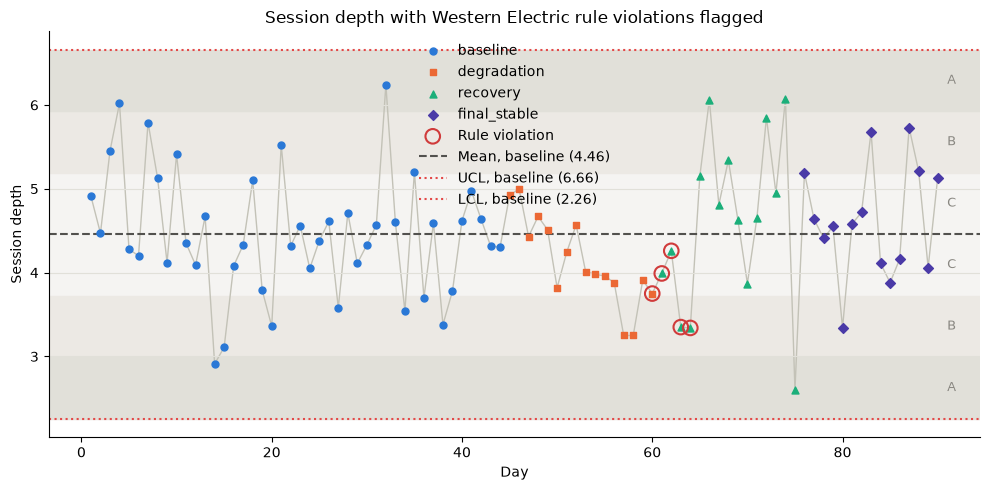

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

# Shaded zones (C closest to mean, A closest to the control limits), mirrored above/below
zone_bounds = [(1, "#f5f4f2"), (2, "#ece9e4"), (3, "#e1e0d9")]
prev = 0
for n_sigma, color in zone_bounds:
    ax.axhspan(mean_val + prev * std_val, mean_val + n_sigma * std_val, color=color, zorder=0)
    ax.axhspan(mean_val - n_sigma * std_val, mean_val - prev * std_val, color=color, zorder=0)
    prev = n_sigma

for label, n_sigma in [("C", 1), ("B", 2), ("A", 3)]:
    ax.text(df["day_index"].max() + 1, mean_val + (n_sigma - 0.5) * std_val, label, color="#898781", fontsize=9, va="center")
    ax.text(df["day_index"].max() + 1, mean_val - (n_sigma - 0.5) * std_val, label, color="#898781", fontsize=9, va="center")

# Connecting line (chronological order) so consecutive-run patterns are easy to trace
ax.plot(df["day_index"], df["session_depth"], color="#c3c2b7", linewidth=1, zorder=1)

# One color + marker shape per period (color-blind safe pair: shape is the secondary encoding)
period_style = {
    "baseline": {"color": "#2a78d6", "marker": "o"},
    "degradation": {"color": "#eb6834", "marker": "s"},
    "recovery": {"color": "#1baf7a", "marker": "^"},
    "final_stable": {"color": "#4a3aa7", "marker": "D"},
}
for period, style in period_style.items():
    subset = df[df["period"] == period]
    ax.scatter(subset["day_index"], subset["session_depth"], color=style["color"], marker=style["marker"],
               s=25, label=period, zorder=3)

# Ring-highlight any point that trips a Western Electric run rule
flagged = df[df["any_rule_flag"]]
ax.scatter(flagged["day_index"], flagged["session_depth"], facecolors="none", edgecolors="#d03b3b",
           s=110, linewidths=1.5, label="Rule violation", zorder=4)

ax.axhline(mean_val, color="#52514e", linestyle="--", linewidth=1.5, label=f"Mean, baseline ({mean_val:.2f})", zorder=2)
ax.axhline(ucl, color="#e34948", linestyle=":", linewidth=1.5, label=f"UCL, baseline ({ucl:.2f})", zorder=2)
ax.axhline(lcl, color="#e34948", linestyle=":", linewidth=1.5, label=f"LCL, baseline ({lcl:.2f})", zorder=2)

ax.set_xlabel("Day")
ax.set_ylabel("Session depth")
ax.set_title("Session depth with Western Electric rule violations flagged")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()